In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd


In [57]:
# 1. PERSIAPAN DATA

In [58]:
df = pd.read_csv('dataset_layer_2023.csv')
df.head(10)

,tanggal,kandang,lokasi,umur_minggu,populasi,mati,produksi_butir,pakan_kg,suhu_c,anomali_flag,total_telur_kg,fcr
0,2023-01-01,K001,Dataran Tinggi,16.0,1500,0,556,189.65,22.0,False,33.36,5.684952
1,2023-01-02,K001,Dataran Tinggi,16.1,1500,0,556,166.29,20.5,False,33.36,4.984712
2,2023-01-03,K001,Dataran Tinggi,16.3,1500,0,556,190.22,20.1,False,33.36,5.702038
3,2023-01-04,K001,Dataran Tinggi,16.4,1500,0,556,167.09,18.0,False,33.36,5.008693
4,2023-01-05,K001,Dataran Tinggi,16.6,1500,0,556,170.26,19.6,False,33.36,5.103717
5,2023-01-06,K001,Dataran Tinggi,16.7,1500,0,556,172.47,18.6,False,33.36,5.169964
6,2023-01-07,K001,Dataran Tinggi,16.9,1500,0,556,176.82,19.2,False,33.36,5.300360
7,2023-01-08,K001,Dataran Tinggi,17.0,1500,0,556,166.71,18.4,False,33.36,4.997302
8,2023-01-09,K001,Dataran Tinggi,17.1,1500,0,556,174.64,18.0,False,33.36,5.235012
9,2023-01-10,K001,Dataran Tinggi,17.3,1500,0,556,188.43,18.0,False,33.36,5.648381


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43760 entries, 0 to 43759
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tanggal         43760 non-null  str    
 1   kandang         43760 non-null  str    
 2   lokasi          43760 non-null  str    
 3   umur_minggu     43760 non-null  float64
 4   populasi        43760 non-null  int64  
 5   mati            43760 non-null  int64  
 6   produksi_butir  43760 non-null  int64  
 7   pakan_kg        43760 non-null  float64
 8   suhu_c          43760 non-null  float64
 9   anomali_flag    43760 non-null  bool   
 10  total_telur_kg  43760 non-null  float64
 11  fcr             43760 non-null  float64
dtypes: bool(1), float64(5), int64(3), str(3)
memory usage: 3.7 MB


In [60]:
df.describe()

,umur_minggu,populasi,mati,produksi_butir,pakan_kg,suhu_c,total_telur_kg,fcr
count,43760.000000,43760.000000,43760.000000,43760.000000,43760.000000,43760.000000,43760.000000,43760.000000
mean,55.000000,1499.279662,0.009575,1036.069516,168.203737,26.576559,62.164171,2.822156
std,22.558319,2.685106,0.098085,198.195084,10.599565,4.007220,11.891705,0.656445
min,16.000000,1470.000000,0.000000,386.000000,144.990000,18.000000,23.160000,1.980584
25%,35.400000,1500.000000,0.000000,851.000000,160.820000,24.000000,51.060000,2.334698
50%,55.000000,1500.000000,0.000000,1091.000000,167.950000,26.600000,65.460000,2.575819
75%,74.600000,1500.000000,0.000000,1198.000000,175.990000,29.500000,71.880000,3.274083
max,94.000000,1500.000000,3.000000,1392.000000,191.100000,38.000000,83.520000,7.003454


In [61]:
#1.2 menghitung hdp
df['hdp'] = (df['produksi_butir']/df['populasi'])*100

In [62]:
#1.3 menghitung produksi telur per (KG)

df['telur_kg'] = df['produksi_butir']*60/1000

In [63]:
#1.4 menghitung fcr
df['fcr'] = df['pakan_kg']/df['telur_kg']
print(f" Rata-Rata FCR = {df['fcr'].mean():.2f}")

 Rata-Rata FCR = 2.82


In [64]:
#1.5 cek data hilang
df.isnull().sum(), df[df['fcr'].isna()]

(tanggal           0
 kandang           0
 lokasi            0
 umur_minggu       0
 populasi          0
 mati              0
 produksi_butir    0
 pakan_kg          0
 suhu_c            0
 anomali_flag      0
 total_telur_kg    0
 fcr               0
 hdp               0
 telur_kg          0
 dtype: int64,
 Empty DataFrame
 Columns: [tanggal, kandang, lokasi, umur_minggu, populasi, mati, produksi_butir, pakan_kg, suhu_c, anomali_flag, total_telur_kg, fcr, hdp, telur_kg]
 Index: [])

In [65]:
#1.6 outlier extrem fcr
df = df[df['fcr'].between(1.5,5.0)]

In [66]:
# STATISTIK DESKRIPTIF

In [67]:
#2.1 statistik fcr
df.describe()

,umur_minggu,populasi,mati,produksi_butir,pakan_kg,suhu_c,total_telur_kg,fcr,hdp,telur_kg
count,42982.000000,42982.000000,42982.000000,42982.000000,42982.000000,42982.000000,42982.000000,42982.000000,42982.000000,42982.000000
mean,55.665707,1499.267531,0.009748,1045.017286,168.125458,26.625057,62.701037,2.777115,69.694422,62.701037
std,22.173563,2.706099,0.098960,188.362771,10.614720,4.000901,11.301766,0.568870,12.526849,11.301766
min,16.000000,1470.000000,0.000000,525.000000,144.990000,18.000000,31.500000,1.980584,35.000000,31.500000
25%,36.400000,1500.000000,0.000000,860.000000,160.712500,24.000000,51.600000,2.331542,57.333333,51.600000
50%,55.700000,1500.000000,0.000000,1096.000000,167.870000,26.700000,65.760000,2.563754,73.066667,65.760000
75%,74.900000,1500.000000,0.000000,1199.000000,175.910000,29.600000,71.940000,3.234796,79.933333,71.940000
max,94.000000,1500.000000,3.000000,1392.000000,191.100000,38.000000,83.520000,4.999701,92.800000,83.520000


In [68]:
#2.2 statistik per kandang fcr
df.groupby('kandang')['fcr'].agg(['mean', 'std', 'min', 'max']).sort_values('mean')

,mean,std,min,max
kandang,,,,
K025,2.658616,0.550616,1.986466,4.964245
K029,2.674554,0.570970,1.988705,4.873843
K048,2.678768,0.548874,1.996063,4.943134
K067,2.680675,0.558445,1.989600,4.912728
K009,2.681166,0.585666,1.983824,4.984181
...,...,...,...,...
K066,2.895313,0.583829,2.158497,4.893333
K039,2.897783,0.558599,2.185819,4.565250
K057,2.910190,0.581585,2.168946,4.959048


In [69]:
#2.3 statistik per lokasi fcr
df.groupby('lokasi')['fcr'].agg(['mean','std','min','max'])

,mean,std,min,max
lokasi,,,,
Dataran Rendah,2.786232,0.567658,1.980584,4.996825
Dataran Sedang,2.776167,0.567048,1.986466,4.999701
Dataran Tinggi,2.787923,0.567915,1.983824,4.997302
Pesisir,2.758214,0.572417,1.989600,4.994921


<Axes: xlabel='lokasi', ylabel='fcr'>

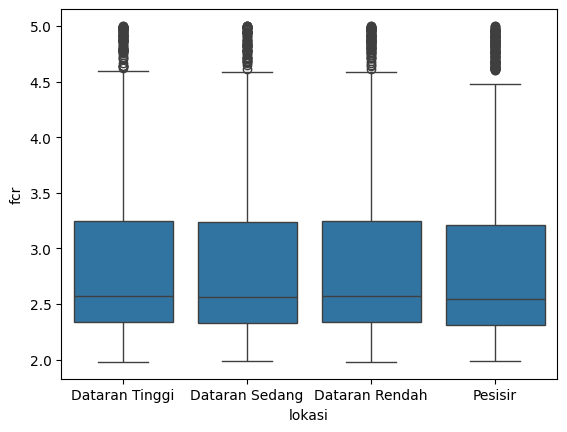

In [70]:
#2.4 Boxplot per lokasi
sns.boxplot(x='lokasi', y='fcr', data=df)

<Axes: xlabel='bulan'>

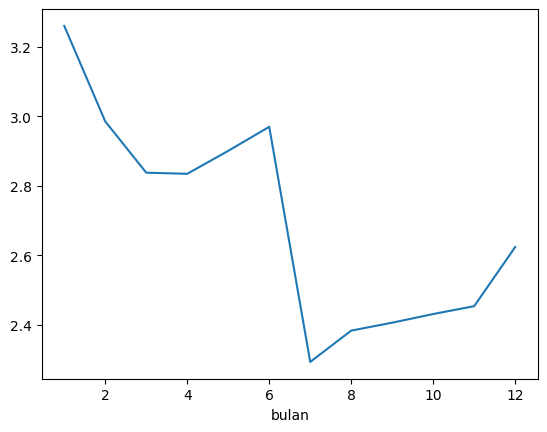

In [71]:
#2.5 statistik per bulan fcr
df['bulan'] = pd.to_datetime(df['tanggal']).dt.month
df.groupby('bulan')['fcr'].mean().plot()

In [72]:
#3. ANALISIS PERBEDAAN ANTAR LOKASI (ANOVA & TUKEY)

In [73]:
#3.1 ANOVA
T = df[df['lokasi']=='Dataran Tinggi']['fcr'].dropna()
S = df[df['lokasi']=='Dataran Sedang']['fcr'].dropna()
R = df[df['lokasi']=='Dataran Rendah']['fcr'].dropna()
P = df[df['lokasi']=='Pesisir']['fcr'].dropna()

t_stat, p_value = f_oneway(T,S,R,P)

print(f"Statistik >>>>>> : {t_stat:.4f}")
print(f"Intercep >>>>>>> : {p_value}")

if p_value < 0.05:
    print('Ada Perbedaan Signifikan Antar Lokasi')
else:
    print('Tidak Ada Perbedaan Signifikan Antar Lokasi')

Statistik >>>>>> : 6.1904
Intercep >>>>>>> : 0.00033588970064331043
Ada Perbedaan Signifikan Antar Lokasi


In [74]:
#3.2 TUKEY
tukey = pairwise_tukeyhsd(endog=df['fcr'], groups=df['lokasi'], alpha=0.05)
print(tukey)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------
Dataran Rendah Dataran Sedang  -0.0101 0.5652   -0.03  0.0099  False
Dataran Rendah Dataran Tinggi   0.0017 0.9964 -0.0183  0.0216  False
Dataran Rendah        Pesisir   -0.028 0.0017 -0.0479 -0.0081   True
Dataran Sedang Dataran Tinggi   0.0118 0.4289 -0.0082  0.0317  False
Dataran Sedang        Pesisir   -0.018 0.0947 -0.0379   0.002  False
Dataran Tinggi        Pesisir  -0.0297 0.0007 -0.0496 -0.0098   True
--------------------------------------------------------------------


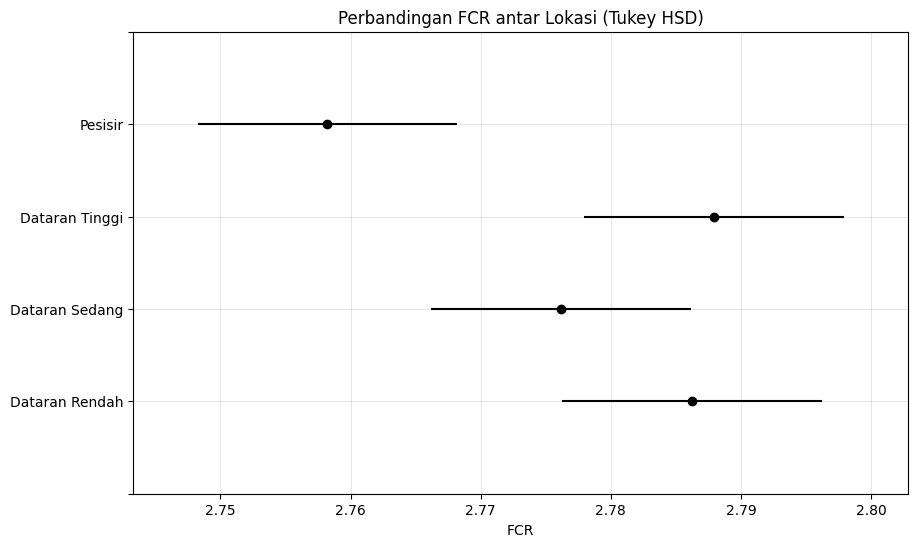

In [75]:
fig = tukey.plot_simultaneous()
plt.xlabel('FCR')
plt.title('Perbandingan FCR antar Lokasi (Tukey HSD)')
plt.grid(True, alpha=0.3)

In [76]:
# 4. ANALISI KORELASI

In [77]:
#4.1 Pilih data numerik
df_num = df.select_dtypes(include='number')

In [78]:
#4.2 Korelasi
corr = df_num.corr()
corr

,umur_minggu,populasi,mati,produksi_butir,pakan_kg,suhu_c,total_telur_kg,fcr,hdp,telur_kg,bulan
umur_minggu,1.000000,-0.346361,0.123195,-0.508407,-0.001611,0.032391,-0.508407,0.443800,-0.507053,-0.508407,0.131934
populasi,-0.346361,1.000000,-0.345357,0.335385,0.107096,-0.305473,0.335385,-0.302841,0.328773,0.335385,0.050949
mati,0.123195,-0.345357,1.000000,-0.119471,-0.036727,0.104611,-0.119471,0.106993,-0.117183,-0.119471,-0.023021
produksi_butir,-0.508407,0.335385,-0.119471,1.000000,0.161446,-0.029416,1.000000,-0.933649,0.999975,1.000000,0.389328
pakan_kg,-0.001611,0.107096,-0.036727,0.161446,1.000000,-0.368516,0.161446,0.152229,0.161018,0.161446,0.009469
suhu_c,0.032391,-0.305473,0.104611,-0.029416,-0.368516,1.000000,-0.029416,-0.066369,-0.027174,-0.029416,0.070362
total_telur_kg,-0.508407,0.335385,-0.119471,1.000000,0.161446,-0.029416,1.000000,-0.933649,0.999975,1.000000,0.389328
fcr,0.443800,-0.302841,0.106993,-0.933649,0.152229,-0.066369,-0.933649,1.000000,-0.933731,-0.933649,-0.391809
hdp,-0.507053,0.328773,-0.117183,0.999975,0.161018,-0.027174,0.999975,-0.933731,1.000000,0.999975,0.389893
telur_kg,-0.508407,0.335385,-0.119471,1.000000,0.161446,-0.029416,1.000000,-0.933649,0.999975,1.000000,0.389328


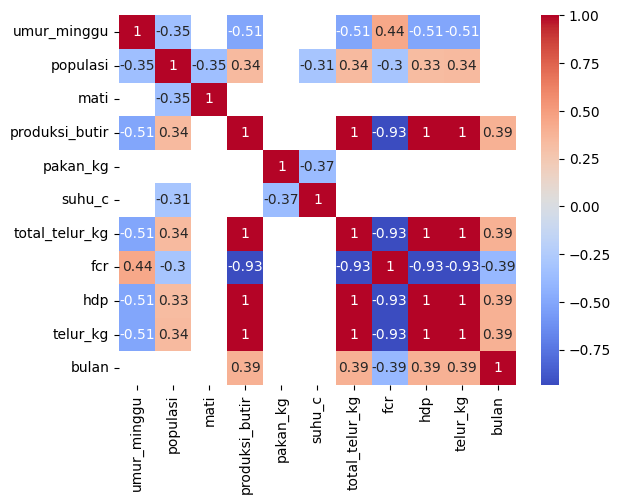

In [ ]:
#4.3 heatmap korelasi
batas= 0.2
mask = np.abs(corr)< batas

sns.heatmap(corr, annot=True, mask=mask, cmap='coolwarm')
plt.show()

In [80]:
#5. DETEKSI ANOMALI FCR

In [81]:
#5.1 Metode IQR

q1 = df['fcr'].quantile(0.25)
q3 = df['fcr'].quantile(0.75)

iqr = q3-q1
print(f"IQR : {iqr:.4f}")

IQR : 0.9033


In [82]:
#5.2 Tentukan batas
batas_atas = q3 + 1.5*iqr 
print(f"Batas Atas : {batas_atas : .4f}")

Batas Atas :  4.5897


In [83]:
#5.3 tandai anomali
df['anomali_fcr'] = df['fcr'] > batas_atas

In [84]:
# 5.4 jumlah anomali
print(f" Jumlah Anomali : {df['anomali_fcr'].sum()}")
print(f" Anomali fcr% : {(df['anomali_fcr'].sum())/(df['fcr'].sum())*100 :.2f}% ")

 Jumlah Anomali : 369
 Anomali fcr% : 0.31% 


In [85]:
# 5.5 anomali per kandang
df.groupby('lokasi')['anomali_fcr'].sum().sort_values()

lokasi
Dataran Sedang     72
Dataran Tinggi     82
Dataran Rendah     86
Pesisir           129
Name: anomali_fcr, dtype: int64

In [86]:
#6. VISUALISASI lAMPIRAN

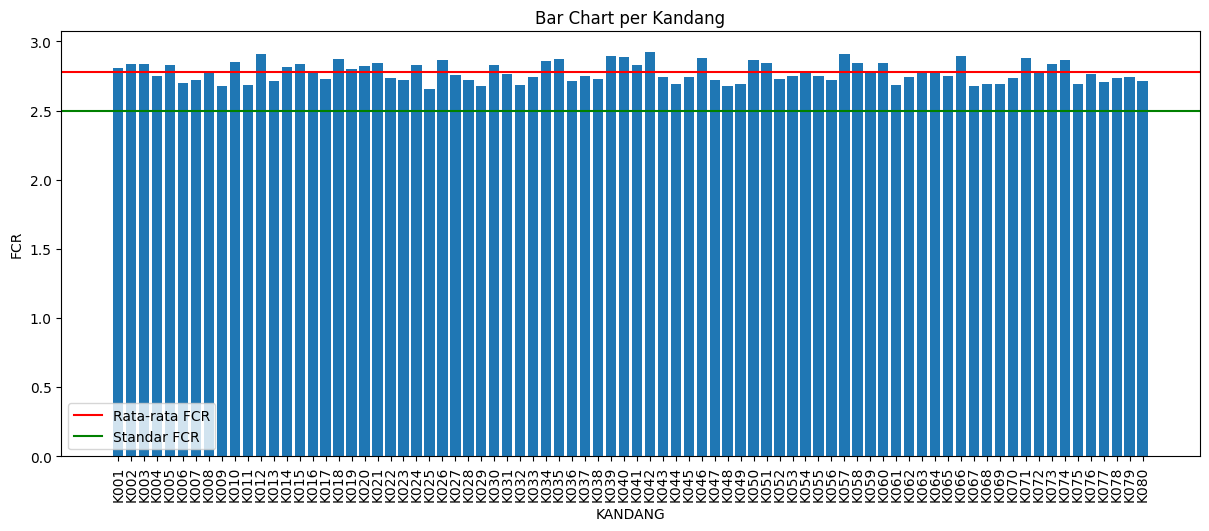

In [87]:
#6.1 Bar chart FCR per kandang
rank  = df.groupby('kandang')['fcr'].agg('mean')
garis_mean = df['fcr'].mean()

plt.figure(figsize=(12,5))
plt.bar(rank.index, rank.values)
plt.axhline(y=garis_mean, color='red', label='Rata-rata FCR')
plt.axhline(y=2.5, color='green', label='Standar FCR')
plt.xticks(rotation=(90))
plt.tight_layout()
plt.ylabel('FCR')
plt.xlabel('KANDANG')
plt.title('Bar Chart per Kandang')
plt.legend()

<Axes: xlabel='kandang', ylabel='fcr'>

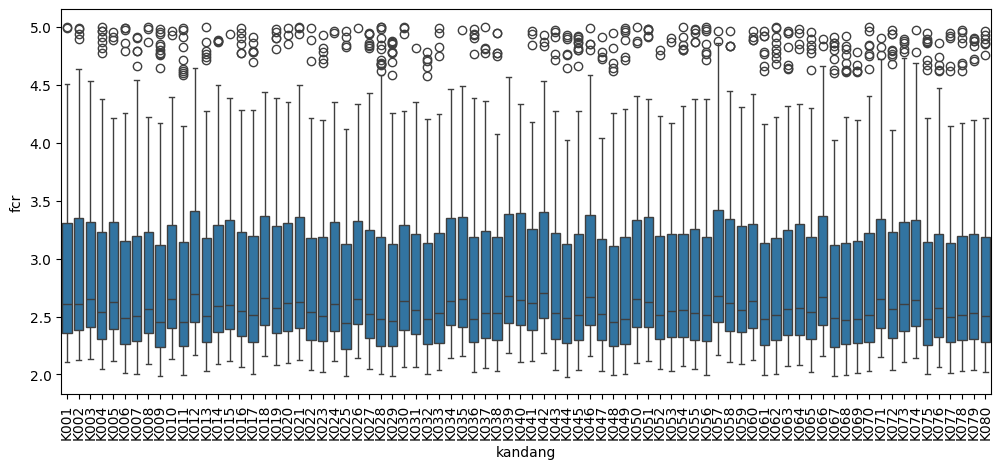

In [88]:
#6.2 Boxplot per kandang
plt.figure(figsize=(12,5))
plt.xticks(rotation=(90))
sns.boxplot(x='kandang', y='fcr', data=df)

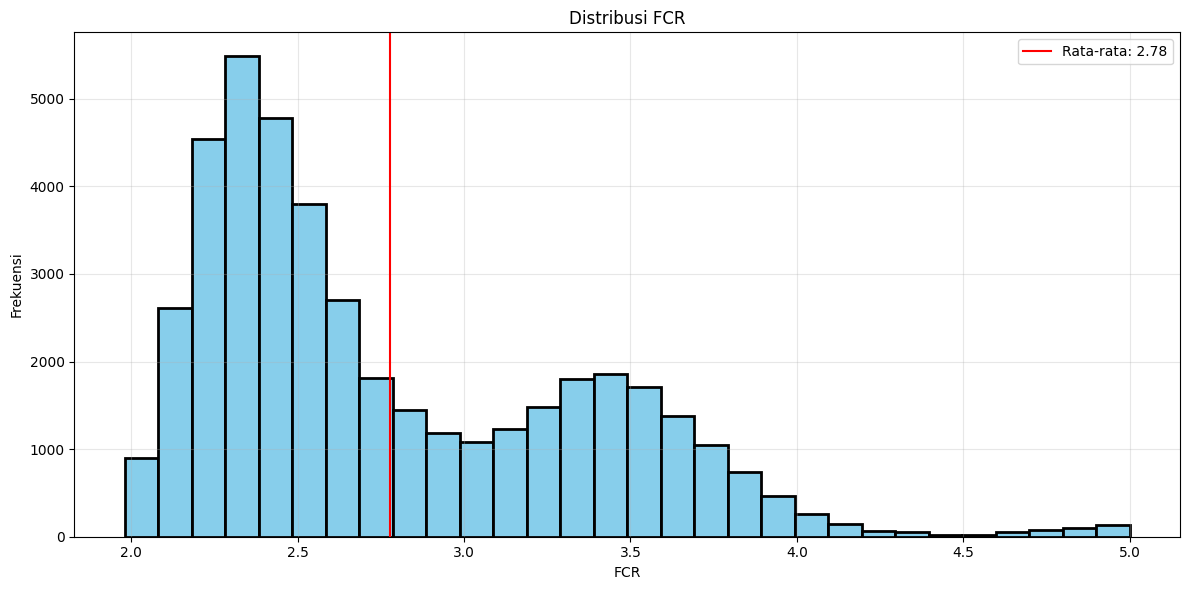

In [89]:
#6.3 Histogram distribusi FCR
garis_mean = df['fcr'].mean()

plt.figure(figsize=(12,6))
plt.hist(df['fcr'], bins=30 ,edgecolor='black', color='skyblue',linestyle='-', linewidth=2)
plt.axvline(x=garis_mean,  color='red', label=f"Rata-rata: {garis_mean:.2f}")
plt.grid(True, alpha = 0.3)
plt.ylabel('Frekuensi')
plt.xlabel('FCR')
plt.legend()
plt.title('Distribusi FCR')
plt.tight_layout()

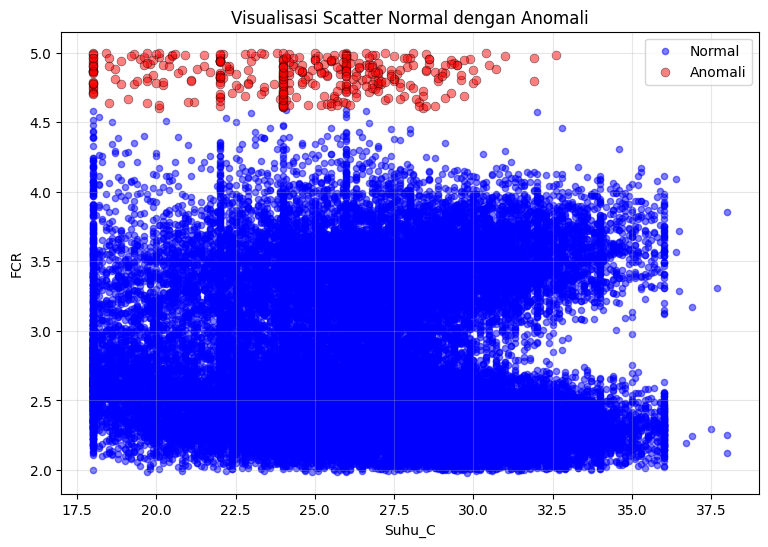

In [99]:
#6.4 Visualisasi Scatter Normal dengan Anomali

datanormal = df[~df['anomali_fcr']]
dataanomali = df[df['anomali_fcr']]
plt.figure(figsize=(9,6))
plt.scatter(datanormal['suhu_c'],datanormal['fcr'], alpha=0.5 , c='blue', label='Normal', s=20)
plt.scatter(dataanomali['suhu_c'],dataanomali['fcr'], alpha=0.5 , c='red', label='Anomali', s=40 ,edgecolors='black' ,linewidths=0.5)
plt.ylabel('FCR')
plt.xlabel('Suhu_C')
plt.title('Visualisasi Scatter Normal dengan Anomali')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [100]:
#7. DAMPAK FINANSIAL

In [101]:
#7.1 target fcr
target_fcr = 2.5
#Ini bedasarkan rata - rata beberapa literatur

In [102]:
#7.2 Hitung kelebihan pakan
df['pakan_berlebih'] = (df['fcr']-target_fcr) * df['telur_kg']
pakan_berlebih = (df['fcr']-target_fcr) * df['telur_kg']

In [103]:
#7.3 Hanya hitung jika positif
df['pakan_berlebih'] = df['pakan_berlebih'].clip(lower=0)

In [104]:
#7.4 Total kerugian
harga_pakan = 7000
total_kerugian = df['pakan_berlebih'].sum() * harga_pakan
print(f"Total Kerugian = Rp {total_kerugian: ,}")

Total Kerugian = Rp  5,375,567,119.999999


In [105]:
#7.5 Kerugian per lokasi
kerugian_per_lokasi = df.groupby('lokasi')['pakan_berlebih'].sum() * harga_pakan
kerugian_per_lokasi


lokasi
Dataran Rendah    1.331738e+09
Dataran Sedang    1.379273e+09
Dataran Tinggi    1.430077e+09
Pesisir           1.234480e+09
Name: pakan_berlebih, dtype: float64

In [106]:
persen = (df.groupby('lokasi')['pakan_berlebih'].sum() * harga_pakan).transform(lambda x: x / x.sum() * 100).round(2)
persen

lokasi
Dataran Rendah    24.77
Dataran Sedang    25.66
Dataran Tinggi    26.60
Pesisir           22.96
Name: pakan_berlebih, dtype: float64

In [107]:
total_telur_per_lokasi = df.groupby('lokasi')['telur_kg'].sum()
(kerugian_per_lokasi / total_telur_per_lokasi).round(2).sort_values()

lokasi
Pesisir           1923.49
Dataran Sedang    1996.33
Dataran Rendah    2018.55
Dataran Tinggi    2035.49
dtype: float64